# 01 — Parse quality and dataset coverage

This notebook checks whether `raw_responses.jsonl` has been successfully converted into `parsed_responses.jsonl`. It separates a software/prompt-compliance question from the substantive cognitive-linguistic question. If structured prompts fail to parse, that is evidence about output reliability rather than image-schema understanding.

In [1]:
from __future__ import annotations
import json
from pathlib import Path
from collections import Counter
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

PROJECT_ROOT = Path("..").resolve()
DATA_DIR = PROJECT_ROOT / "data"
PARSED_PATH = DATA_DIR / "outputs" / "parsed_responses.jsonl"
RAW_PATH = DATA_DIR / "outputs" / "raw_responses.jsonl"
GOLD_PATH = DATA_DIR / "gold" / "sentences_v1.jsonl"

def read_jsonl(path: Path) -> pd.DataFrame:
    records = []
    if not path.exists():
        raise FileNotFoundError(f"File not found: {path}")
    with path.open("r", encoding="utf-8") as f:
        for line_no, line in enumerate(f, start=1):
            if line.strip():
                records.append(json.loads(line))
    return pd.DataFrame(records)

def safe_accuracy(df: pd.DataFrame, pred_col: str, gold_col: str):
    if pred_col not in df.columns or gold_col not in df.columns:
        return None
    sub = df[df[pred_col].notna() & df[gold_col].notna()]
    if sub.empty:
        return None
    return float((sub[pred_col].astype(str) == sub[gold_col].astype(str)).mean())

def pct(x):
    return "NA" if x is None or pd.isna(x) else f"{100*x:.1f}%"

In [2]:
parsed = read_jsonl(PARSED_PATH)
print(f"Parsed records: {len(parsed)}")
display(parsed.head())

Parsed records: 5400


,run_key,run_index,provider,model_id,model_name,prompt_id,prompt_family,prompt_version,condition_id,condition_family,...,path,goal,obstacle,force,source_domain,target_domain,interpretation,schema_explanation,confidence,parsed_json
0,openai_gpt_5_4_mini|p_naive_v1|c_temp_0_v1|s00...,0,openai,openai_gpt_5_4_mini,gpt-5.4-mini,p_naive_v1,naive,v1.0,c_temp_0_v1,deterministic,...,,,,,[],[],It means the keys are located inside the box.,,NaN,{}
1,openai_gpt_5_4_mini|p_naive_v1|c_temp_0_v1|s00...,1,openai,openai_gpt_5_4_mini,gpt-5.4-mini,p_naive_v1,naive,v1.0,c_temp_0_v1,deterministic,...,,,,,[],[],It means the child went inside the tent by cli...,,NaN,{}
2,gemini_2_5_flash|p_naive_v1|c_temp_0_v1|s0001|0,3600,google,gemini_2_5_flash,gemini-2.5-flash,p_naive_v1,naive,v1.0,c_temp_0_v1,deterministic,...,,,,,[],[],The keys are physically located inside the box.,,NaN,{}
3,gemini_2_5_flash|p_naive_v1|c_temp_0_v1|s0002|0,3601,google,gemini_2_5_flash,gemini-2.5-flash,p_naive_v1,naive,v1.0,c_temp_0_v1,deterministic,...,,,,,[],[],"A young person moved their body, likely using ...",,NaN,{}
4,claude_sonnet_4_6|p_naive_v1|c_temp_0_v1|s0001|0,1800,anthropic,claude_sonnet_4_6,claude-sonnet-4-6,p_naive_v1,naive,v1.0,c_temp_0_v1,deterministic,...,,,,,[],[],## Interpretation\n\nThe sentence simply tells...,,NaN,{}


In [3]:
parse_counts = parsed["parse_status"].value_counts(dropna=False).rename_axis("parse_status").reset_index(name="count")
parse_counts["percent"] = parse_counts["count"] / parse_counts["count"].sum()
display(parse_counts)

,parse_status,count,percent
0,parsed,2751,0.509444
1,free_text_unparsed,1800,0.333333
2,parse_error,849,0.157222


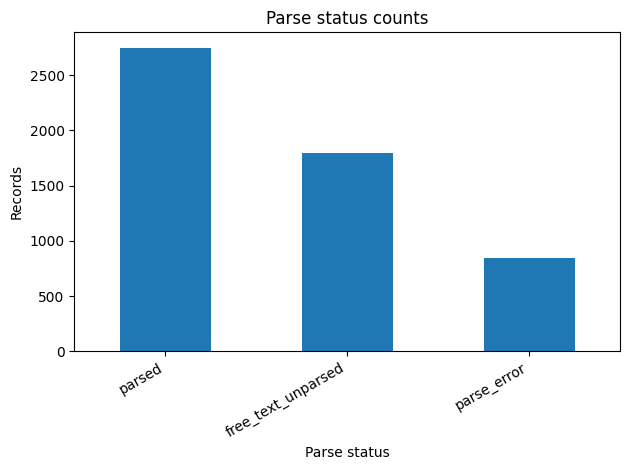

In [4]:
ax = parse_counts.plot(kind="bar", x="parse_status", y="count", legend=False)
ax.set_title("Parse status counts")
ax.set_xlabel("Parse status")
ax.set_ylabel("Records")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

In [5]:
if "prompt_family" in parsed.columns:
    display(pd.crosstab(parsed["prompt_family"], parsed["parse_status"], margins=True))

parse_status,free_text_unparsed,parse_error,parsed,All
prompt_family,,,,
direct_schema,0,342,1458,1800
naive,1800,0,0,1800
structured_role_based,0,507,1293,1800
All,1800,849,2751,5400


In [6]:
if "prompt_family" in parsed.columns:
    expected = parsed.assign(
        expected_parse_status=np.where(parsed["prompt_family"].eq("naive"), "free_text_unparsed", "parsed")
    )
    expected["parse_matches_prompt_type"] = expected["parse_status"] == expected["expected_parse_status"]
    display(expected.groupby("prompt_family")["parse_matches_prompt_type"].agg(["count", "mean"]))

,count,mean
prompt_family,,
direct_schema,1800,0.810000
naive,1800,1.000000
structured_role_based,1800,0.718333


## Interpretation guide

- Naïve/free-text prompts should normally appear as `free_text_unparsed`.
- Direct-schema and structured-role prompts should normally appear as `parsed`.
- A high `parse_error` rate means the project is measuring prompt/output compliance problems before it can measure schema interpretation.